# Social Media Post Engagement Prediction
## Step 1: Import Libraries 



In [33]:

# 1. Import Libraries

import pandas as pd                  # For data handling
import numpy as np                   # For numerical operations

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and train-test split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
# Evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report



In [34]:

# 2. Load Dataset


df = pd.read_csv('social_media_engagement_dataset.csv')

# Preview first 5 rows
df.head()

,platform,post_type,post_length,views,likes,comments,shares,engagement_rate
0,Facebook,Text,62,91660,2968,276,346,0.039166
1,Instagram,Video,104,113115,4164,632,406,0.045989
2,Facebook,Video,46,36043,3125,188,100,0.094692
3,Facebook,Image,39,124886,5970,948,578,0.060023
4,Instagram,Video,42,82831,8212,1104,334,0.116502


### Step 2a: Check Missing Values


In [35]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
platform           0
post_type          0
post_length        0
views              0
likes              0
comments           0
shares             0
engagement_rate    0
dtype: int64


### Step 2b: Target Categorization

#### We will convert engagement_rate into three categories:
#### Low: 0-2%, Medium: 2-5%, High: >5%

In [36]:
# Function to categorize engagement rate
def categorize_engagement(rate):
    if rate < 0.02:          # 0-2% → Low
        return 'Low'
    elif rate < 0.05:        # 2-5% → Medium
        return 'Medium'
    else:                    # >5% → High
        return 'High'

# Apply function to create new target column
df['engagement_level'] = df['engagement_rate'].apply(categorize_engagement)

# Drop original numeric engagement_rate column
df = df.drop('engagement_rate', axis=1)

# Preview the dataset to confirm
df.head()

,platform,post_type,post_length,views,likes,comments,shares,engagement_level
0,Facebook,Text,62,91660,2968,276,346,Medium
1,Instagram,Video,104,113115,4164,632,406,Medium
2,Facebook,Video,46,36043,3125,188,100,High
3,Facebook,Image,39,124886,5970,948,578,High
4,Instagram,Video,42,82831,8212,1104,334,High


### Step 2c: Encode Categorical Features
#### Our dataset has categorical columns:
#### - platform
#### - post_type
#### We will convert them into numeric form using One-Hot Encoding

In [37]:

df = pd.get_dummies(df, columns=['platform', 'post_type'], drop_first=True)

# Check dataset after encoding
df.head()

,post_length,views,likes,comments,shares,engagement_level,platform_Instagram,platform_Twitter,post_type_Text,post_type_Video
0,62,91660,2968,276,346,Medium,False,False,True,False
1,104,113115,4164,632,406,Medium,True,False,False,True
2,46,36043,3125,188,100,High,False,False,False,True
3,39,124886,5970,948,578,High,False,False,False,False
4,42,82831,8212,1104,334,High,True,False,False,True


### Step 2d: Separate Features and Target
#### X → input features (used for prediction)
#### y → target variable (what we want to predict)

In [38]:

X = df.drop('engagement_level', axis=1)
Y = df['engagement_level']

# Check shapes
print("Shape of X:", X.shape)
print("Shape of Y:", Y.shape)

Shape of X: (10000, 9)
Shape of Y: (10000,)


### Step 2e: Encode Target Variable


In [39]:
# Create LabelEncoder object
le = LabelEncoder()

# Convert target labels into numbers
y = le.fit_transform(Y)



### Step 2f: Train-Test Split


In [40]:
 #Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



### Step 2g: Feature Scaling


In [41]:
#Create StandardScaler object
scaler = StandardScaler()

# Fit on training data and transform it
X_train = scaler.fit_transform(X_train)

# Only transform test data (IMPORTANT)
X_test = scaler.transform(X_test)



## Step 3: Logistic Regression Model


In [42]:
# Create Logistic Regression model
log_model = LogisticRegression()

# Train the model
log_model.fit(X_train, y_train)

# Make predictions
y_pred_log = log_model.predict(X_test)




### Step 3b: Model Evaluation (Logistic Regression)

#### We will evaluate the model using:
#### 1. Accuracy Score
#### 2. Confusion Matrix
#### 3. Classification Report

In [64]:
# Accuracy
log_accuracy = accuracy_score(y_test, y_pred_log)
print("Logistic Regression Accuracy:", log_accuracy)

# Confusion Matrix
print("\nConfusion Matrix:")
log_confusion_matrix= confusion_matrix(y_test,y_pred_log)
print(log_confusion_matrix)


# Classification Report
print("\nClassification Report:")
log_classification_report=classification_report(y_test, y_pred_log)
print(log_classification_report)


Logistic Regression Accuracy: 0.9645

Confusion Matrix:
[[1308    0    4]
 [   0  114   42]
 [  20    5  507]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1312
           1       0.96      0.73      0.83       156
           2       0.92      0.95      0.93       532

    accuracy                           0.96      2000
   macro avg       0.95      0.89      0.92      2000
weighted avg       0.96      0.96      0.96      2000



## Step 4: Decision Tree Classifier



In [44]:
# Create Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test)



### Step 4b: Model Evaluation (Decision Tree)

#### We will check:
#### 1. Accuracy
#### 2. Confusion Matrix
#### 3. Classification Report

In [65]:
#Accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", dt_accuracy)

# Confusion Matrix
print("\nConfusion Matrix:")
dt_confusion_matrix= confusion_matrix(y_test,y_pred_dt)
print(dt_confusion_matrix)


# Classification Report
print("\nClassification Report:")
dt_classification_report=classification_report(y_test, y_pred_dt)
print(dt_classification_report)


Decision Tree Accuracy: 0.9445

Confusion Matrix:
[[1275    0   37]
 [   0  135   21]
 [  36   17  479]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1312
           1       0.89      0.87      0.88       156
           2       0.89      0.90      0.90       532

    accuracy                           0.94      2000
   macro avg       0.92      0.91      0.91      2000
weighted avg       0.94      0.94      0.94      2000



## Step 5: Random Forest Classifier



In [46]:
# Create Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)



### Step 5b: Model Evaluation (Random Forest)

#### We will check:
#### 1. Accuracy
#### 2. Confusion Matrix
#### 3. Classification Report

In [66]:
# Accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)

# Confusion Matrix
print("\nConfusion Matrix:")
rf_confusion_matrix= confusion_matrix(y_test,y_pred_rf)
print(rf_confusion_matrix)


# Classification Report
print("\nClassification Report:")
rf_classification_report=classification_report(y_test, y_pred_rf)
print(rf_classification_report)


Random Forest Accuracy: 0.9595

Confusion Matrix:
[[1291    0   21]
 [   0  133   23]
 [  34    3  495]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      1312
           1       0.98      0.85      0.91       156
           2       0.92      0.93      0.92       532

    accuracy                           0.96      2000
   macro avg       0.96      0.92      0.94      2000
weighted avg       0.96      0.96      0.96      2000



## Step 6: Support Vector Machine (SVM)



In [48]:
# Create SVM model
svm_model = SVC(kernel='rbf', random_state=42)

# Train the model
svm_model.fit(X_train, y_train)

# Make predictions
y_pred_svm = svm_model.predict(X_test)



### Step 6b: Model Evaluation (SVM)
#### We will check:
#### 1. Accuracy
#### 2. Confusion Matrix
#### 3. Classification Report

In [67]:
# Accuracy
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", svm_accuracy)

# Confusion Matrix
print("\nConfusion Matrix:")
svm_confusion_matrix= confusion_matrix(y_test,y_pred_svm)
print(svm_confusion_matrix)


# Classification Report
print("\nClassification Report:")
svm_classification_report=classification_report(y_test, y_pred_svm)
print(svm_classification_report)


SVM Accuracy: 0.9265

Confusion Matrix:
[[1307    0    5]
 [   7   84   65]
 [  62    8  462]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1312
           1       0.91      0.54      0.68       156
           2       0.87      0.87      0.87       532

    accuracy                           0.93      2000
   macro avg       0.91      0.80      0.84      2000
weighted avg       0.93      0.93      0.92      2000



## Step 7: K-Nearest Neighbors (KNN)


In [50]:
# Create KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)  # k=5 neighbors

# Train the model
knn_model.fit(X_train, y_train)

# Make predictions
y_pred_knn = knn_model.predict(X_test)



### Step 7b: Model Evaluation (KNN)
#### We will check:
#### 1. Accuracy
#### 2. Confusion Matrix
#### 3. Classification Report

In [68]:
# Accuracy
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", knn_accuracy)

# Confusion Matrix
print("\nConfusion Matrix:")
knn_confusion_matrix= confusion_matrix(y_test,y_pred_knn)
print(knn_confusion_matrix)


# Classification Report
print("\nClassification Report:")
knn_classification_report=classification_report(y_test, y_pred_knn)
print(knn_classification_report)


KNN Accuracy: 0.867

Confusion Matrix:
[[1246    1   65]
 [   6   79   71]
 [  89   34  409]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      1312
           1       0.69      0.51      0.59       156
           2       0.75      0.77      0.76       532

    accuracy                           0.87      2000
   macro avg       0.79      0.74      0.76      2000
weighted avg       0.86      0.87      0.86      2000



## Step 8: Naive Bayes


In [52]:
# Create Naive Bayes model
nb_model = GaussianNB()

# Train the model
nb_model.fit(X_train, y_train)

# Make predictions
y_pred_nb = nb_model.predict(X_test)



### Step 8b: Model Evaluation (Naive Bayes)
#### We will check:
#### 1. Accuracy
#### 2. Confusion Matrix
#### 3. Classification Report

In [69]:
# Accuracy
nb_accuracy = accuracy_score(y_test, y_pred_nb)
print("Naive Bayes Accuracy:", nb_accuracy)

# Confusion Matrix
print("\nConfusion Matrix:")
nb_confusion_matrix= confusion_matrix(y_test,y_pred_nb)
print(nb_confusion_matrix)

# Classification Report
print("\nClassification Report:")
nb_classification_report=classification_report(y_test, y_pred_nb)
print(nb_classification_report)

Naive Bayes Accuracy: 0.587

Confusion Matrix:
[[785 185 342]
 [  0 121  35]
 [ 80 184 268]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.60      0.72      1312
           1       0.25      0.78      0.37       156
           2       0.42      0.50      0.46       532

    accuracy                           0.59      2000
   macro avg       0.52      0.63      0.52      2000
weighted avg       0.73      0.59      0.62      2000



## Step 9: Compare All Models
### Now we will compare the accuracy of all models
### and visualize the results using a bar chart.


Logistic Regression Accuracy: 0.9645
Decision Tree Accuracy: 0.9445
Random Forest Accuracy: 0.9595
SVM (RBF) Accuracy: 0.9265
KNN Accuracy: 0.867
Naive Bayes Accuracy: 0.587


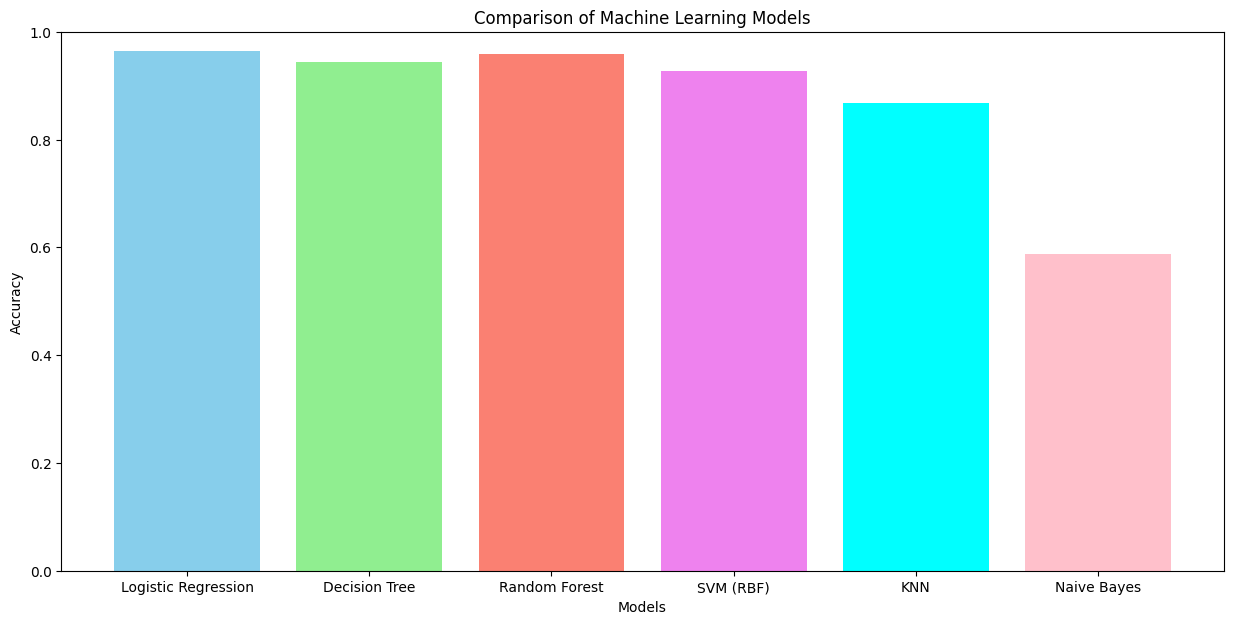

In [54]:
# Print accuracies directly
print("Logistic Regression Accuracy:", log_accuracy)
print("Decision Tree Accuracy:", dt_accuracy)
print("Random Forest Accuracy:", rf_accuracy)
print("SVM (RBF) Accuracy:", svm_accuracy)
print("KNN Accuracy:", knn_accuracy)
print("Naive Bayes Accuracy:", nb_accuracy)
# Visualization using bar chart
plt.figure(figsize=(15,7))
plt.bar(
    ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM (RBF)','KNN','Naive Bayes'],
    [log_accuracy, dt_accuracy, rf_accuracy, svm_accuracy,knn_accuracy,nb_accuracy],
    color=['skyblue','lightgreen','salmon','violet','cyan','pink']
)
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.title("Comparison of Machine Learning Models")
plt.ylim(0,1)
plt.show()

## Step 10: Predict Engagement Level on New Data


In [58]:
new_data=pd.DataFrame({
    'post_length':[120],
    'views':[50000],
    'likes':[4000],
    'comments':[350],
    'shares':[200],
    'platform_Instagram':[1], 
    'platform_Twitter':[0],
    'post_type_Text':[0],
    'post_type_Video':[1]
})


In [59]:
new_data_scaled=scaler.transform(new_data)


In [61]:
log_pred=log_model.predict(new_data_scaled)
dt_pred=dt_model.predict(new_data_scaled)
rf_pred=rf_model.predict(new_data_scaled)
svm_pred=svm_model.predict(new_data_scaled)
knn_pred=knn_model.predict(new_data_scaled)
nb_pred=nb_model.predict(new_data_scaled)
print("Logistic Regression :", le.inverse_transform(log_pred))
print("Decision Tree :", le.inverse_transform(dt_pred))
print("Random Forest :", le.inverse_transform(rf_pred))
print("SVM  :", le.inverse_transform(svm_pred))
print("KNN :", le.inverse_transform(knn_pred))
print("Naive Bayes:", le.inverse_transform(nb_pred))

Logistic Regression : ['High']
Decision Tree : ['High']
Random Forest : ['High']
SVM  : ['High']
KNN : ['High']
Naive Bayes: ['Medium']
